<a href="https://colab.research.google.com/github/abhiniveshg0-max/DEEP-LEARNING/blob/main/experiment%201%20part%20A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 1.0428 - mae: 0.6708 - val_loss: 0.4669 - val_mae: 0.4961
Epoch 2/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.4147 - mae: 0.4554 - val_loss: 0.4166 - val_mae: 0.4562
Epoch 3/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3697 - mae: 0.4319 - val_loss: 0.3925 - val_mae: 0.4397
Epoch 4/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3513 - mae: 0.4198 - val_loss: 0.3826 - val_mae: 0.4391
Epoch 5/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3421 - mae: 0.4119 - val_loss: 0.3666 - val_mae: 0.4290
Epoch 6/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4272 - mae: 0.4149 - val_loss: 0.3603 - val_mae: 0.4106
Epoch 7/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3267 - mae: 0.3973 - val_loss: 0.3627 - val_mae: 0.4365
Epoch 8/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3143 - mae: 0.3928 - val_loss: 0.3416 - val_mae: 0.4026
Epoch 9/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - l

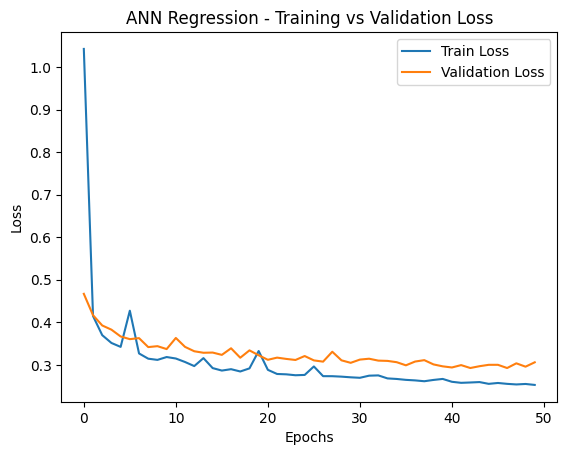

In [1]:
# EXPT NO: 1 - PART A: ANN FOR REGRESSION
# Dataset: California Housing Dataset
# Roll No: <YOUR_ROLL_NO_HERE>

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. Load the California Housing dataset
data = fetch_california_housing()
X, y = data.data, data.target

# 2. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 4. Build the ANN model
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)   # Linear output for regression
])

# 5. Compile the model
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# 6. Train the model
history = model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=50,
    batch_size=32,
    verbose=1
)

# 7. Predict house prices
y_pred = model.predict(X_test).flatten()

# 8. Evaluate the model
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"MSE  : {mse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")

# 9. Plot training loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("ANN Regression - Training vs Validation Loss")
plt.legend()
plt.savefig("regression_loss_curve.png")
plt.show()